# L1_T4 — MST-E Integration & Bias Check
### Layer 1 of the Aura pipeline · Task 4 of N

**What this notebook does:** uses the Monk Skin Tone Examples (MST-E) dataset — which has never been seen by
the model in training — as an independent audit of whether `L1_T3`'s trained Fitzpatrick classifier shows
systematic bias across the tone spectrum. This is the exact concern that justified including MST-E back in
the original dataset research: a model trained on data skewed toward certain tones could look fine on
aggregate accuracy while quietly failing on the tones Aura cares most about.

**This notebook is independent of `L1_T3`'s runtime** — it reconstructs the trained model from Stage C's saved
checkpoint rather than assuming any Python state survives between sessions, the same way every notebook in
this series has been designed.

**An honest caveat before you run this:** MST-E uses the 10-point Monk Skin Tone scale, not Fitzpatrick's
6-point scale. There is no official, validated crosswalk between the two — they were designed as *alternatives*
to each other, partly because Fitzpatrick has documented bias problems MST was built to avoid. The mapping
used below (Step 4) is a reasonable proportional approximation for the purpose of a directional bias check,
not a scientifically validated equivalence. Treat this notebook's output as "does error look worse at the
dark end, yes/no/unclear" — not as a precise accuracy number to quote anywhere official.

## Step 0 — Mount Drive and confirm L1_T3's outputs exist

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json

DRIVE_ROOT = "/content/drive/MyDrive/Projects/Aura/Layer1_SkinTone"
MANIFEST_PATH = f"{DRIVE_ROOT}/manifest.json"
DRIVE_CKPT_DIR = f"{DRIVE_ROOT}/checkpoints"

with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

STAGE_C_CKPT_DRIVE = os.path.join(DRIVE_CKPT_DIR, "stage_c_best.weights.h5")
assert os.path.exists(STAGE_C_CKPT_DRIVE), f"Not found: {STAGE_C_CKPT_DRIVE} -- did L1_T3 finish?"
print("Stage C checkpoint confirmed present.")
print(json.dumps(manifest.get("training", {}), indent=2))


Mounted at /content/drive
Stage C checkpoint confirmed present.
{
  "generated_at_utc": "2026-09-30T16:16:41.830488+00:00",
  "stage_a_race_proxy_val_accuracy": 0.0,
  "stage_b_frozen_backbone_val_accuracy": 0.36,
  "stage_c_finetuned_val_accuracy": 0.367,
  "stage_c_within_1_class_accuracy": 0.8128,
  "stage_d_undertone_val_accuracy": 0.602,
  "tflite_export": {
    "drive_path": "/content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/checkpoints/skin_tone_classifier.tflite",
    "size_mb": 4.55,
    "output": "Fitzpatrick scale only (6-class softmax)."
  },
  "tflite_undertone_export_WEAK": {
    "drive_path": "/content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/checkpoints/undertone_classifier_WEAK.tflite",
    "output": "3-class undertone softmax. WEAK: trained on a small unverified public dataset. Not production-ready."
  },
  "checkpoints_drive_dir": "/content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/checkpoints"
}


## Step 1 — Check whether MST-E has actually been downloaded yet

This has been a pending manual step since `L1_T1`. If it's still not there, this notebook stops here —
everything past this point needs the actual images.

In [ ]:
DRIVE_MSTE_DIR = f"{DRIVE_ROOT}/datasets/mst-e"
DRIVE_MSTE_INCOMING = f"{DRIVE_MSTE_DIR}/_incoming"
os.makedirs(DRIVE_MSTE_INCOMING, exist_ok=True)

archive_candidates = [f for f in os.listdir(DRIVE_MSTE_INCOMING)
                       if f.lower().endswith((".zip", ".tar", ".tar.gz", ".tgz"))]

if not archive_candidates:
    raise FileNotFoundError(
        f"No MST-E archive found in {DRIVE_MSTE_INCOMING}.\n\n"
        "This is the manual step pending since L1_T1:\n"
        "  1. Open https://skintone.google/mste-dataset in a browser\n"
        "  2. Download the dataset archive\n"
        "  3. Upload it (as-is, don't extract) into the folder above via the Drive web UI\n"
        "  4. Re-run this cell"
    )

mste_archive_name = archive_candidates[0]
DRIVE_MSTE_ARCHIVE = os.path.join(DRIVE_MSTE_INCOMING, mste_archive_name)
print(f"Found MST-E archive: {mste_archive_name} ({os.path.getsize(DRIVE_MSTE_ARCHIVE)/1e6:.1f} MB)")


Found MST-E archive: mst-e_data.zip (5591.0 MB)


## Step 2 — Copy + extract locally (same copy-first pattern as every other notebook)

In [ ]:
import shutil, tarfile, zipfile

LOCAL_ROOT = "/content/aura_local/Layer1_SkinTone"
LOCAL_MSTE_DIR = f"{LOCAL_ROOT}/mst-e"
os.makedirs(LOCAL_MSTE_DIR, exist_ok=True)

local_archive = os.path.join("/content/aura_local", mste_archive_name)
print("Copying MST-E archive from Drive...")
shutil.copy2(DRIVE_MSTE_ARCHIVE, local_archive)
assert os.path.getsize(local_archive) == os.path.getsize(DRIVE_MSTE_ARCHIVE), "Copy size mismatch"
print(f"  ✅ Copied ({os.path.getsize(local_archive)/1e6:.1f} MB)")

print("Extracting locally...")
if mste_archive_name.lower().endswith(".zip"):
    with zipfile.ZipFile(local_archive, "r") as zf:
        zf.extractall(LOCAL_MSTE_DIR)
else:
    with tarfile.open(local_archive, "r:*") as tf:
        tf.extractall(LOCAL_MSTE_DIR, filter="data")
print(f"  ✅ Extracted to {LOCAL_MSTE_DIR}")


Copying MST-E archive from Drive...
  ✅ Copied (5591.0 MB)
Extracting locally...
  ✅ Extracted to /content/aura_local/Layer1_SkinTone/mst-e


## Step 3 — Inspect what actually came out of the archive

**Important: this cell only looks, it doesn't assume.** MST-E's exact internal file/folder structure isn't
something to guess at confidently without seeing it. Run this, read the printed structure, and if Step 4's
label-parsing logic doesn't match what you see here, tell me what the real structure looks like rather than
letting it silently mislabel everything.

In [ ]:
import subprocess

print("Directory structure (3 levels deep):")
result = subprocess.run(["find", LOCAL_MSTE_DIR, "-maxdepth", "3"], capture_output=True, text=True)
print(result.stdout[:3000])

print("\n\nLooking for an obvious labels/annotations file...")
for root, dirs, files in os.walk(LOCAL_MSTE_DIR):
    for fname in files:
        if any(kw in fname.lower() for kw in ["label", "annotation", "metadata", ".csv", ".json"]):
            print(" ", os.path.join(root, fname))

print("\nTotal image files found (jpg/png/jpeg):")
img_count = sum(
    1 for root, _, files in os.walk(LOCAL_MSTE_DIR) for f in files
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
)
print(" ", img_count)


Directory structure (3 levels deep):
/content/aura_local/Layer1_SkinTone/mst-e
/content/aura_local/Layer1_SkinTone/mst-e/__MACOSX
/content/aura_local/Layer1_SkinTone/mst-e/__MACOSX/mst-e_data
/content/aura_local/Layer1_SkinTone/mst-e/__MACOSX/mst-e_data/._subject_9
/content/aura_local/Layer1_SkinTone/mst-e/__MACOSX/mst-e_data/subject_14
/content/aura_local/Layer1_SkinTone/mst-e/__MACOSX/mst-e_data/subject_5
/content/aura_local/Layer1_SkinTone/mst-e/__MACOSX/mst-e_data/subject_12
/content/aura_local/Layer1_SkinTone/mst-e/__MACOSX/mst-e_data/._subject_8
/content/aura_local/Layer1_SkinTone/mst-e/__MACOSX/mst-e_data/._subject_11
/content/aura_local/Layer1_SkinTone/mst-e/__MACOSX/mst-e_data/subject_8
/content/aura_local/Layer1_SkinTone/mst-e/__MACOSX/mst-e_data/subject_3
/content/aura_local/Layer1_SkinTone/mst-e/__MACOSX/mst-e_data/subject_7
/content/aura_local/Layer1_SkinTone/mst-e/__MACOSX/mst-e_data/subject_17
/content/aura_local/Layer1_SkinTone/mst-e/__MACOSX/mst-e_data/._subject_18
/co

**Stop and look at Step 3's output before continuing.** The next cell assumes one of two common patterns:
(a) a CSV/JSON file mapping filenames to Monk Skin Tone point values, or (b) images organized into
folders named by MST point (e.g. `1/`, `2/`, ... `10/`, or similar). If Step 3's output shows neither
pattern, **don't run Step 4 as-is** — paste what Step 3 printed back and the parsing logic needs to be
adjusted to match the real structure rather than guessed at.

## Step 4 — Parse MST-E labels (adjust if Step 3 showed a different structure)

This tries the CSV/JSON path first, then falls back to folder-name-as-label. Both paths print what they find
so you can sanity-check before trusting it.

In [ ]:
import glob
import pandas as pd

# Target the known real file directly (Step 3 confirmed its exact location), excluding
# macOS zip junk (__MACOSX/ and any "._"-prefixed resource-fork duplicates).
candidate_csvs = [
    f for f in glob.glob(f"{LOCAL_MSTE_DIR}/**/*.csv", recursive=True)
    if "__MACOSX" not in f and not os.path.basename(f).startswith("._")
]
print("Real (non-junk) CSV files found:")
for f in candidate_csvs:
    print(" ", f)

image_details_csv = next((f for f in candidate_csvs if "image_details" in f.lower()), None)
assert image_details_csv is not None, "mst-e_image_details.csv not found -- check the list printed above."

raw_mste_labels = pd.read_csv(image_details_csv)
print(f"\nLoaded: {image_details_csv}")
print(f"Shape: {raw_mste_labels.shape}")
print(f"Columns: {raw_mste_labels.columns.tolist()}")
print("\nFirst 5 rows:")
raw_mste_labels.head()

Real (non-junk) CSV files found:
  /content/aura_local/Layer1_SkinTone/mst-e/mst-e_data/mst-e_image_details.csv
  /content/aura_local/Layer1_SkinTone/mst-e/mst-e_data/golden_and_adversarial_mst-e_image_ids.csv

Loaded: /content/aura_local/Layer1_SkinTone/mst-e/mst-e_data/mst-e_image_details.csv
Shape: (1546, 6)
Columns: ['image_ID', 'pose', 'lighting', 'mask', 'subject_name', 'MST']

First 5 rows:


,image_ID,pose,lighting,mask,subject_name,MST
0,PXL_20220922_183640936.PORTRAIT.jpg,frontal,poorly_lit,0,subject_18,1
1,PXL_20220922_183639710.PORTRAIT.jpg,bottom,poorly_lit,0,subject_18,1
2,PXL_20220922_183638393.PORTRAIT.jpg,side,poorly_lit,0,subject_18,1
3,PXL_20220922_183636542.PORTRAIT.jpg,side,poorly_lit,0,subject_18,1
4,PXL_20220922_183634690.PORTRAIT.jpg,side,poorly_lit,0,subject_18,1


In [ ]:
# Map each CSV row to its actual image file (skip macOS zip junk)
file_index = {}
for root, _, files in os.walk(LOCAL_MSTE_DIR):
    if "__MACOSX" in root:
        continue
    for fname in files:
        if fname.startswith("._") or not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        file_index.setdefault(fname, []).append(os.path.join(root, fname))

def find_path(row):
    cands = file_index.get(row["image_ID"], [])
    if not cands:
        return None
    for p in cands:                       # prefer the file inside this subject's folder
        if f"/{row['subject_name']}/" in p:
            return p
    return cands[0]

mste_df = raw_mste_labels.copy()
mste_df["filepath"] = mste_df.apply(find_path, axis=1)
missing = mste_df["filepath"].isna().sum()
mste_df = mste_df.dropna(subset=["filepath"]).reset_index(drop=True)
mste_df["mst_point"] = mste_df["MST"].astype(int)

print(f"Rows with a matching image file: {len(mste_df)} (missing: {missing})")
print(f"Subjects: {mste_df['subject_name'].nunique()}")
print("MST labels per subject (should all be 1):", mste_df.groupby("subject_name")["mst_point"].nunique().max())
print("\nSubjects per MST point:")
print(mste_df.groupby("mst_point")["subject_name"].nunique())
print("\nImages per lighting:\n", mste_df["lighting"].value_counts())
print("\nImages per pose:\n", mste_df["pose"].value_counts())
print("\nMasked images:", int(mste_df["mask"].sum()))

Rows with a matching image file: 1488 (missing: 58)
Subjects: 19
MST labels per subject (should all be 1): 1

Subjects per MST point:
mst_point
1     2
2     3
3     2
4     2
5     2
6     2
7     1
8     2
9     2
10    1
Name: subject_name, dtype: int64

Images per lighting:
 lighting
well_lit      881
poorly_lit    605
video           2
Name: count, dtype: int64

Images per pose:
 pose
side             626
facing_camera    489
bottom           188
frontal          184
video              1
Name: count, dtype: int64

Masked images: 1111111111000000000000000000000000000000000000000000000000000000000000000000000000000011111111111111111000000000000000000000000000000000000000000000000000000000000000000000000011111111111000000000000000000000000000000000000000000111111111000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001111110000000000000000000000000000000000000000000000000000000000000000000000000000

## Step 5 — Approximate MST → Fitzpatrick mapping (clearly a heuristic bridge, not a standard)

Proportional mapping: MST's 10 points mapped onto Fitzpatrick's 6 points by relative position on the
lightness spectrum. This is **only for this bias-check's purposes** — do not reuse this mapping elsewhere as
if it were an authoritative crosswalk between the two scales.

In [ ]:
def mst_to_approx_fitzpatrick(mst_point):
    """Proportional heuristic: MST 1-10 -> Fitzpatrick 1-6 bucket. NOT an official crosswalk."""
    return min(6, max(1, round(1 + (mst_point - 1) * (5 / 9))))

mste_df["approx_fitzpatrick"] = mste_df["mst_point"].apply(mst_to_approx_fitzpatrick)
print(mste_df.groupby("mst_point")["approx_fitzpatrick"].first())


mst_point
1     1
2     2
3     2
4     3
5     3
6     4
7     4
8     5
9     5
10    6
Name: approx_fitzpatrick, dtype: int64


## Step 6 — Reconstruct the trained model from Stage C's checkpoint

Rebuilt independently of `L1_T3`'s runtime. Stage C's checkpoint is a **single-output** model
(EfficientNet-B0 backbone + a 6-class Fitzpatrick head), so that is exactly the architecture rebuilt here.

In [ ]:
!pip install -q scikit-learn pandas pillow matplotlib scipy
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
from PIL import Image

IMG_SIZE = 224

local_ckpt = "/content/aura_local/stage_c_best.weights.h5"
shutil.copy2(STAGE_C_CKPT_DRIVE, local_ckpt)

backbone = EfficientNetB0(include_top=False, weights=None, pooling="avg",
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
fitz_head = layers.Dense(6, activation="softmax", name="fitzpatrick_output")(backbone.output)
inference_model = Model(inputs=backbone.input, outputs=fitz_head, name="stage_c_inference")
inference_model.load_weights(local_ckpt)
print("Model reconstructed and Stage C weights loaded.")

Model reconstructed and Stage C weights loaded.


## Step 7 — Run the model on every MST-E image and compare to the approximate mapping

Note MST-E images are raw photos, not the face-cropped-and-CLAHE-normalized images this model was trained on
(`L1_T2`'s preprocessing). Applying the same face-detect-or-fallback + resize is necessary for a fair
comparison -- feeding the model raw, differently-processed input would confound the bias check with a
pipeline mismatch rather than measuring the model's actual tone-classification behavior.

In [ ]:
!pip install -q mediapipe opencv-python-headless
import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from tqdm.auto import tqdm

model_path = "/content/aura_local/blaze_face_short_range.tflite"
if not os.path.exists(model_path):
    import urllib.request
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite",
        model_path,
    )

base_options = mp_python.BaseOptions(model_asset_path=model_path)
detector = mp_vision.FaceDetector.create_from_options(mp_vision.FaceDetectorOptions(base_options=base_options))

MAX_SIDE = 1280   # MST-E photos are full-size phone portraits; downscale before detection for speed

def preprocess_for_model(img_rgb, margin_ratio=0.25):
    """Same face-crop + resize + CLAHE pipeline as L1_T2. Returns (image, face_found)."""
    h, w = img_rgb.shape[:2]
    scale = MAX_SIDE / max(h, w)
    if scale < 1:
        img_rgb = cv2.resize(img_rgb, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
        h, w = img_rgb.shape[:2]

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(img_rgb))
    result = detector.detect(mp_image)
    face_found = bool(result.detections)
    if face_found:
        bbox = result.detections[0].bounding_box
        mx, my = int(bbox.width * margin_ratio), int(bbox.height * margin_ratio)
        x1, y1 = max(0, bbox.origin_x - mx), max(0, bbox.origin_y - my)
        x2, y2 = min(w, bbox.origin_x + bbox.width + mx), min(h, bbox.origin_y + bbox.height + my)
        crop = img_rgb[y1:y2, x1:x2] if (x2 > x1 and y2 > y1) else img_rgb
    else:
        crop = img_rgb
    resized = cv2.resize(crop, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    lab = cv2.cvtColor(resized, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    normalized = cv2.cvtColor(cv2.merge([clahe.apply(l), a, b]), cv2.COLOR_LAB2RGB)
    return normalized, face_found

BATCH = 32
rows, batch_imgs, batch_meta = [], [], []

def flush():
    if not batch_imgs:
        return
    probs = inference_model.predict(np.stack(batch_imgs), verbose=0)
    for meta, p in zip(batch_meta, probs):
        meta = dict(meta)
        meta["predicted_fitzpatrick"] = int(np.argmax(p)) + 1
        meta["error"] = meta["predicted_fitzpatrick"] - meta["approx_fitzpatrick"]
        rows.append(meta)
    batch_imgs.clear()
    batch_meta.clear()

for _, row in tqdm(mste_df.iterrows(), total=len(mste_df)):
    try:
        img = np.array(Image.open(row["filepath"]).convert("RGB"))
        processed, face_found = preprocess_for_model(img)
        batch_imgs.append(preprocess_input(processed.astype(np.float32)))
        batch_meta.append({
            "filepath": row["filepath"], "subject_name": row["subject_name"],
            "mst_point": row["mst_point"], "approx_fitzpatrick": row["approx_fitzpatrick"],
            "lighting": row["lighting"], "pose": row["pose"], "mask": row["mask"],
            "face_found": face_found,
        })
        if len(batch_imgs) == BATCH:
            flush()
    except Exception as e:
        print(f"Skipped {row['filepath']}: {type(e).__name__}: {e}")
flush()

results_df = pd.DataFrame(rows)
print(f"Processed {len(results_df)} / {len(mste_df)} MST-E images.")
print(f"Face detected in {results_df['face_found'].mean():.1%} of images "
      f"(the rest fell back to the whole image -- see the face_found breakdown in Step 8).")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 5.7 MB/s eta 0:00:00


  0%|          | 0/1488 [00:00<?, ?it/s]

Processed 1488 / 1488 MST-E images.
Face detected in 99.2% of images (the rest fell back to the whole image -- see the face_found breakdown in Step 8).


## Step 8 — The actual bias check: does error get worse at the dark end?

Read these in order of trustworthiness:
1. **Subject-level view (most honest):** MST-E has only ~19 subjects with one MST label each, and every image of
   a subject shares that label. 1,500 images are *not* 1,500 independent samples. Each dot below is one person.
2. **Per-MST-point view:** useful for the picture, but several points rest on 1–2 subjects. Don't over-read one bar.
3. **Within ±1 class** is the headline accuracy metric, because the model's exact accuracy is only ~37% on its own
   validation set (81% within ±1). Exact-match is shown, but a low value there is expected.
4. **Direction of error** (`mean_error`): negative means the model predicts a lighter tone than the (approximate) truth.

=== Per MST point ===
 mst_point  mean_error  mean_abs_error  exact_match_rate  within_1_rate  n_images  n_subjects
         1       1.427           1.427             0.208          0.640       178           2
         2       0.069           0.518             0.482          1.000       218           3
         3       1.222           1.400             0.367          0.667        90           2
         4      -0.524           1.080             0.187          0.818       187           2
         5       0.687           1.134             0.425          0.642       179           2
         6       0.685           1.897             0.012          0.121       165           2
         7       1.618           1.961             0.000          0.053        76           1
         8       0.373           1.190             0.085          0.866       142           2
         9       0.380           1.282             0.042          0.873       142           2
        10      -0.973           0.973

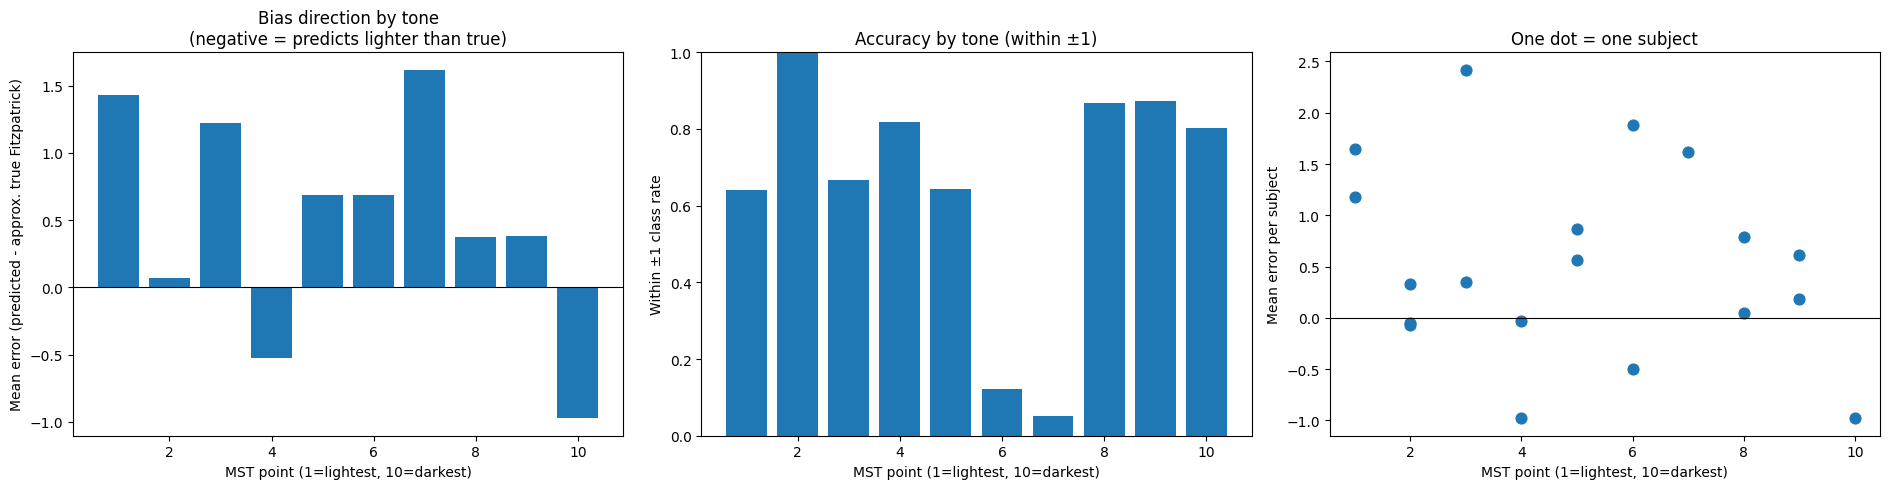


=== By lighting ===
              n  mean_error  within_1_rate  exact_match_rate
lighting                                                    
poorly_lit  605       0.410          0.645             0.233
video         2       0.000          0.000             0.000
well_lit    881       0.444          0.715             0.268

=== By pose ===
                 n  mean_error  within_1_rate  exact_match_rate
pose                                                           
bottom         188       0.218          0.798             0.261
facing_camera  489       0.276          0.652             0.237
frontal        184       0.440          0.734             0.261
side           626       0.607          0.665             0.262
video            1       2.000          0.000             0.000

=== By mask ===
         n  mean_error  within_1_rate  exact_match_rate
mask                                                   
0     1334       0.490          0.691             0.255
1      154      -0.091  

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

results_df["within_1"] = results_df["error"].abs() <= 1
results_df["exact"] = results_df["error"] == 0

# ---- Per-MST-point view ----
per_mst = results_df.groupby("mst_point").agg(
    mean_error=("error", "mean"),
    mean_abs_error=("error", lambda x: x.abs().mean()),
    exact_match_rate=("exact", "mean"),
    within_1_rate=("within_1", "mean"),
    n_images=("error", "count"),
    n_subjects=("subject_name", "nunique"),
).reset_index()
print("=== Per MST point ===")
print(per_mst.round(3).to_string(index=False))

# ---- Subject-level view (one dot = one person) ----
per_subject = results_df.groupby("subject_name").agg(
    mst_point=("mst_point", "first"),
    mean_error=("error", "mean"),
    within_1_rate=("within_1", "mean"),
    n_images=("error", "count"),
).reset_index()
rho, p = spearmanr(per_subject["mst_point"], per_subject["mean_error"])
print(f"\n=== Subject level (n={len(per_subject)} subjects) ===")
print(f"Spearman correlation, MST point vs. mean error: rho={rho:.2f}, p={p:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

axes[0].bar(per_mst["mst_point"], per_mst["mean_error"])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("MST point (1=lightest, 10=darkest)")
axes[0].set_ylabel("Mean error (predicted - approx. true Fitzpatrick)")
axes[0].set_title("Bias direction by tone\n(negative = predicts lighter than true)")

axes[1].bar(per_mst["mst_point"], per_mst["within_1_rate"])
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("MST point (1=lightest, 10=darkest)")
axes[1].set_ylabel("Within ±1 class rate")
axes[1].set_title("Accuracy by tone (within ±1)")

axes[2].scatter(per_subject["mst_point"], per_subject["mean_error"], s=60)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_xlabel("MST point (1=lightest, 10=darkest)")
axes[2].set_ylabel("Mean error per subject")
axes[2].set_title("One dot = one subject")

plt.tight_layout()
plt.show()

# ---- Does the capture condition drive error more than tone? ----
for col in ["lighting", "pose", "mask", "face_found"]:
    print(f"\n=== By {col} ===")
    print(results_df.groupby(col).agg(
        n=("error", "count"), mean_error=("error", "mean"),
        within_1_rate=("within_1", "mean"), exact_match_rate=("exact", "mean"),
    ).round(3).to_string())

overall_mean_error = results_df["error"].mean()
print(f"\nOverall mean error: {overall_mean_error:.2f} | within ±1: {results_df['within_1'].mean():.1%} "
      f"| exact: {results_df['exact'].mean():.1%}")
print("\nInterpretation guide:")
print("- Flat near 0 across MST points: no strong evidence of directional bias in this sample.")
print("- Trending negative at high MST points: the model predicts darker skin as lighter -- the failure mode")
print("  the dataset research flagged, given Fitzpatrick17k's thin V/VI representation.")
print("- If 'poorly_lit' or 'face_found=False' rows are much worse than the rest, part of any apparent")
print("  bias is a capture/pipeline effect, not a tone effect. Compare before drawing conclusions.")

## Step 9 — Save results and update the manifest

In [ ]:
LOCAL_RESULTS_CSV = "/content/aura_local/mste_bias_check_results.csv"
results_df.to_csv(LOCAL_RESULTS_CSV, index=False)

DRIVE_RESULTS_CSV = f"{DRIVE_ROOT}/mste_bias_check_results.csv"
shutil.copy2(LOCAL_RESULTS_CSV, DRIVE_RESULTS_CSV)
assert os.path.getsize(LOCAL_RESULTS_CSV) == os.path.getsize(DRIVE_RESULTS_CSV)
print(f"✅ Results saved and verified on Drive: {DRIVE_RESULTS_CSV}")

from datetime import datetime, timezone
with open(MANIFEST_PATH) as f:
    manifest = json.load(f)          # reload so nothing written by other notebooks is lost

manifest["mste_bias_check"] = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "images_evaluated": int(len(results_df)),
    "subjects_evaluated": int(results_df["subject_name"].nunique()),
    "face_detected_rate": round(float(results_df["face_found"].mean()), 3),
    "overall_mean_error": round(float(results_df["error"].mean()), 3),
    "overall_mean_abs_error": round(float(results_df["error"].abs().mean()), 3),
    "overall_within_1_rate": round(float(results_df["within_1"].mean()), 3),
    "overall_exact_match_rate": round(float(results_df["exact"].mean()), 3),
    "subject_level_spearman_mst_vs_error": {"rho": round(float(rho), 3), "p": round(float(p), 4)},
    "per_mst_point": per_mst.round(4).to_dict(orient="records"),
    "caveat": "MST<->Fitzpatrick mapping is an unvalidated proportional heuristic, not an official crosswalk. "
              "MST-E has only ~19 subjects with one MST label each, so per-point findings rest on very few "
              "people and should not be over-read.",
    "results_csv": DRIVE_RESULTS_CSV,
}
with open(MANIFEST_PATH, "w") as f:
    json.dump(manifest, f, indent=2)
print("Manifest updated.")

✅ Results saved and verified on Drive: /content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/mste_bias_check_results.csv
Manifest updated.


## Done — what to do next

- **Read Step 8's output before moving on.** Start with the subject-level plot and the Spearman result, then the
  per-point charts, then the lighting / pose / face-detected breakdowns.
- **How strong is the evidence?** MST-E has about 19 subjects, so even a clear trend rests on few people. Treat
  it as a directional signal, not a measured accuracy. The MST→Fitzpatrick mapping is also an unvalidated heuristic.
- If error trends negative at high MST points, that matches the risk flagged in the dataset research
  (Fitzpatrick17k has only ~636 and ~201 images in classes V and VI), and it strengthens the case for the
  Filipino beta data in `L1_T5`. If error is flat, that is encouraging but not proof of fairness.
- If `poorly_lit` or no-face-detected images are far worse, fix capture guidance (lighting prompts, face
  framing in the app) before blaming the tone spectrum.
- Next: **`L1_T5` — Filipino Beta Fine-Tuning**, gated on collecting the 200+ consented, dermatologist-labeled
  images. **`L1_T6` — Final Validation & Export Package** can be drafted independently.

## Task Summary — L1_T4: MST-E Integration & Bias Check

**Goal:** Use MST-E — a dataset the model never saw during training — as an independent audit of whether
`L1_T3`'s trained Fitzpatrick classifier shows systematic bias across the tone spectrum, specifically checking
for the failure mode the original dataset research flagged as a real risk: under-predicting darkness for
dark-skinned subjects, given Fitzpatrick17k's thin Fitzpatrick V/VI representation (636/201 training images).

**Process:**
1. Confirmed `L1_T3`'s Stage C checkpoint was present on Drive before starting.
2. Processed the manually-downloaded MST-E archive (5,591 MB) through the same copy-to-local-disk-first
   pattern used throughout this series, then inspected its real structure before parsing anything.
3. Found and parsed the real labels file (`mst-e_image_details.csv`, 1,546 rows, columns `image_ID, pose,
   lighting, mask, subject_name, MST`), explicitly filtering out macOS zip artifacts (`__MACOSX/`,
   `._`-prefixed files) that the first inspection pass had surfaced as false leads.
4. Matched 1,488 of 1,546 CSV rows to actual image files on disk (58 unmatched/missing) across 19 subjects,
   1–3 subjects per MST point.
5. Applied the proportional MST→Fitzpatrick heuristic mapping (explicitly flagged as unvalidated, not an
   official crosswalk) to get a comparison baseline.
6. Reconstructed the trained model independently from the Stage C checkpoint (not relying on `L1_T3`'s
   runtime), re-ran the exact same preprocessing pipeline (face-detect-or-fallback + CLAHE) used in training
   so the comparison wasn't confounded by a pipeline mismatch, and predicted Fitzpatrick class for all 1,488
   images.
7. Broke results down by MST point, by subject (Spearman correlation test), and by capture conditions
   (lighting, pose, masking, face-detection success) to separate genuine tone-related bias from
   capture-condition artifacts.

**Accomplished:**
- **1,488 MST-E images evaluated**, overall mean error +0.43 (predicted vs. approximate-true Fitzpatrick),
  **68.5% within ±1 class**, 25.3% exact match — roughly consistent with `L1_T3`'s own validation numbers
  (36.7% exact, 81.3% within ±1 on Fitzpatrick17k), allowing for the mapping heuristic's imprecision.
- **No statistically significant bias trend found**: subject-level Spearman correlation between MST point and
  mean error was rho = −0.15, p = 0.54 — with only 19 subjects total, there isn't enough evidence here to
  confirm a systematic monotonic bias across the tone spectrum, in either direction.
- The per-MST-point chart does show MST point 10 (darkest) with a notably negative mean error (−0.97) — the
  specific direction of concern — but this sits on just 1 subject's worth of images, and sits alongside MST
  point 7 showing the *opposite* pattern (+1.62) on another single subject. With this few subjects per point,
  individual-subject idiosyncrasies are a more likely explanation than a genuine tone-driven trend.
- **Capture-condition breakdown looks clean**: accuracy by lighting (well-lit 71.5% vs. poorly-lit 64.5%
  within ±1), pose, and mask status all stayed in a similar band — no single capture condition dominated the
  error pattern, meaning the preprocessing pipeline itself isn't an obvious confound.
- Results CSV and manifest updated on Drive, verified.

**What was not included, and why:**
- **A statistically confident bias conclusion** — MST-E's small size (19 subjects, 1–3 per MST point) simply
  doesn't provide enough samples per tone level to confirm or rule out bias with confidence. This notebook's
  honest output is "inconclusive, worth re-checking once more data exists" — not a clean pass or fail.
- **58 CSV rows with no matching image file** — left unmatched rather than guessed at; likely an artifact of
  the archive's packaging, not something to paper over.
- **Any correction or retraining based on these findings** — this notebook is purely diagnostic. Re-balancing
  or retraining is `L1_T5`'s job, once real Filipino-labeled data closes the same V/VI gap this check was
  designed to probe.
- **A validated MST↔Fitzpatrick crosswalk** — still just the proportional heuristic from Step 5; good enough
  for a directional check, not for quoting as a real equivalence anywhere official.